In [1]:
from mdss.ScoringFunctions.Bernoulli import Bernoulli
from mdss.ScoringFunctions.Poisson import Poisson
from mdss.MDSS import MDSS
import seaborn as sns

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt

In [19]:

import warnings
 # data = pd.read_csv('../sets/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)
data = pd.read_csv('/Users/kayadetunji/Downloads/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)

target_cols = ['diabetes_status_c_phase1', 'ckd_c_phase1', 'cvd_status_phase1', 'hypertension_status_c_phase1']
data.head()

,age_phase1,site,sex,highest_level_of_education_phase1,partnership_status_c_phase1,ses_site_quintile_c_phase1,occupation_phase1,alcohol_use_status_c_phase1,smoking_status_c_phase1,diabetes_history_phase1,...,change_in_triglycerides,change_in_glucose,change_in_s_creatinine,change_in_insulin,change_in_non_hdl,change_in_egfr,change_in_acr,change_in_mvpa,MAP_phase1,MAP_phase2
0,45.0,3,1,2,1,4,1,3,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,88.166667,-999.000000
1,46.0,3,1,1,1,2,3,3,1,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,111.500000,-999.000000
2,57.0,1,0,0,2,2,2,0,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,87.500000,-999.000000
3,56.0,1,0,1,2,4,4,0,0,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,105.666667,-999.000000
4,56.0,1,1,1,2,2,4,3,2,0,...,-0.01,-0.47,15.88,-999.0,-0.73,-14.779267,-0.301724,2870.0,78.000000,62.666667


In [20]:
site_id = 3 # 1 - Agincourt, 3 - Nairobi

# Choose the relevant site and age group
dff = data[(data['site'] == site_id)].fillna(-999)
# dff = dff2[(dff2['site'] == site_id)& (dff2['age_phase1'] <= 60) & (dff2['age_phase1'] >= 40)].fillna(-999)

print('Original size: ', dff.shape)
dff = dff[(dff[target_cols] != -999).sum(axis = 1) == len(target_cols)].copy()
print('Size after removing records with missing targets: ', dff.shape)

Original size:  (1942, 76)
Size after removing records with missing targets:  (1939, 76)


In [21]:
from IPython.display import Math,display, Markdown
Math(r'F(k) = \int_{-\infty}^{\infty} f(x) \cdot PP')

<IPython.core.display.Math object>

In [22]:
display(Math(r'Dims: {}x{}m \\ Area: {}m^2 \\ Volume: {}m^3'))

<IPython.core.display.Math object>

In [23]:
features = ['age_phase1', 'sex', 'highest_level_of_education_phase1',
       'partnership_status_c_phase1', 'ses_site_quintile_c_phase1',
       'occupation_phase1', 'alcohol_use_status_c_phase1',
       'smoking_status_c_phase1', 'diabetes_history_phase1', 'mvpa_c_phase1',
       'weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']
continuous = ['weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']

In [24]:
# dff.loc[:,'ckd_c_qcphase1'] = dff.loc[:,'ckd_c_qcphase1'].replace([-999], 0)
dff1 = dff.replace([-999, -222, -111, 999], np.nan).copy()

In [25]:
from sklearn.linear_model import BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
imputer_bayes = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42)

# let's create a MICE imputer using Bayes as estimator

imputer = IterativeImputer(
    estimator=BayesianRidge(), # the estimator to predict the NA
    initial_strategy='mean', # how will NA be imputed in step 1
    max_iter=10, # number of cycles
    imputation_order='ascending', # the order in which to impute the variables
    n_nearest_features=None, # whether to limit the number of predictors
    skip_complete=True, # whether to ignore variables without NA
    random_state=0,
)
imputer.fit(dff1[continuous])
train_t = imputer.transform(dff1[continuous])
# train_x = imputer.transform(data.iloc[:,2:])
treated = pd.DataFrame(train_t, columns=dff1[continuous].columns)
# treated = treated.apply(np.ceil)
# treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']]\
#       = np.round(treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']], decimals=0)


In [26]:
# variables = {
#     'bmi_c_phase1': 'BMI',
#     'triglycerides_phase1': 'Triglycerides',
#     'egfr_c_phase1': 'EGFR',
#     'cholesterol_1_phase1': 'Cholesterol'
# }
# colors = ['brown', 'lightblue']

# # Create subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for ax, (var, var_name) in zip(axes, variables.items()):
#     dff1[var].plot(kind='kde', ax=ax, color=colors[0], label='Before Imputation')
#     treated[var].plot(kind='kde', ax=ax, color=colors[1], label='After Imputation')
#     ax.set_title(f'Distribution of {var_name}')
#     ax.set_xlabel(var_name)
#     ax.set_ylabel('Density')
#     ax.legend()
#     ax.grid(True)

# plt.tight_layout()
# # Save the figure as .eps
# fig.savefig("/Users/kayadetunji/Downloads/figs/distributions_ag.eps", format='eps')

# # Save the figure as a vector-based PDF
# fig.savefig("/Users/kayadetunji/Downloads/figs/distributions_ag.pdf", format='pdf')
# plt.show()

In [27]:
dff = dff[features + target_cols].copy()
dff.reset_index(inplace=True, drop=True)
dff[continuous] = treated[continuous]
dff['age_phase1'] = dff.age_phase1.astype(int)

In [28]:
# Specify the columns of interest
# columns_of_interest = ['htn_jnc7_qc', 'diabetes_status_c_qc', 'ckd_c_qc', 'cadiovascular_current'] 


# defining the outcome variable
dff['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1) # *******CHECK*********
treated['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1)

# Min-Max Normalization
# treated['normalizedOutcome'] = (treated['MorbidityCount'] - treated['MorbidityCount'].min()) / (treated['MorbidityCount'].max() - treated['MorbidityCount'].min())


# defining the expectations as mean of the target
# treated['expectation'] = treated[target_col].mean()
# treated['expectationPoisson'] = treated['normalizedOutcome'].mean()
treated['expectationPoisson'] = treated['MorbidityCount'].mean()
dff['expectationPoisson'] = dff['MorbidityCount'].mean()

In [29]:
NA = dff
dff_nai = dff

In [12]:
AG = dff
dff_ag = dff


In [30]:
import numpy as np
import pandas as pd

# ============================================================
# USER SETTINGS
# ============================================================

AGE_COL = 'age_phase1'              # <-- change if needed
OUTCOME_COL = 'MorbidityCount'

# ============================================================
# BASIC AGE SUMMARY
# ============================================================

def age_summary(df, site_name, age_col=AGE_COL):
    
    age = pd.to_numeric(df[age_col], errors='coerce').dropna()

    return {
        'Site': site_name,
        'N': len(df),
        'Age_n': len(age),
        'Age_mean': age.mean(),
        'Age_SD': age.std(),
        'Age_median': age.median(),
        'Age_Q1': age.quantile(0.25),
        'Age_Q3': age.quantile(0.75),
        'Age_min': age.min(),
        'Age_max': age.max(),
        'Age_>=45_n': (age >= 45).sum(),
        'Age_>=45_%': 100 * (age >= 45).mean(),
        'Age_>=50_n': (age >= 50).sum(),
        'Age_>=50_%': 100 * (age >= 50).mean(),
        'Age_>=53_n': (age >= 53).sum(),
        'Age_>=53_%': 100 * (age >= 53).mean(),
        'Age_>=54_n': (age >= 54).sum(),
        'Age_>=54_%': 100 * (age >= 54).mean()
    }


age_summary_table = pd.DataFrame([
    age_summary(dff_ag, 'Agincourt'),
    age_summary(dff_nai, 'Nairobi')
])

# round numerical values for display
display_table = age_summary_table.copy()

for col in display_table.columns:
    if col not in ['Site', 'N', 'Age_n',
                   'Age_>=45_n', 'Age_>=50_n',
                   'Age_>=53_n', 'Age_>=54_n']:
        display_table[col] = display_table[col].round(2)

display(display_table)

,Site,N,Age_n,Age_mean,Age_SD,Age_median,Age_Q1,Age_Q3,Age_min,Age_max,Age_>=45_n,Age_>=45_%,Age_>=50_n,Age_>=50_%,Age_>=53_n,Age_>=53_%,Age_>=54_n,Age_>=54_%
0,Agincourt,1395,1395,50.91,5.90,51.0,46.0,56.0,38,70,1116,80.00,849,60.86,601,43.08,532,38.14
1,Nairobi,1939,1939,48.86,5.73,48.0,44.0,53.0,30,67,1412,72.82,825,42.55,537,27.69,438,22.59


In [31]:
# ============================================================
# CREATE COMMON 5-YEAR AGE BANDS ACROSS BOTH SITES
# ============================================================

pooled_age = pd.concat([
    pd.to_numeric(dff_ag[AGE_COL], errors='coerce'),
    pd.to_numeric(dff_nai[AGE_COL], errors='coerce')
]).dropna()

age_start = int(np.floor(pooled_age.min() / 5) * 5)
age_end = int(np.ceil((pooled_age.max() + 1) / 5) * 5)

age_bins = np.arange(age_start, age_end + 1, 5)

print("Age-bin edges:", age_bins)


def prepare_site(df, site_name):
    temp = df.copy()
    temp['Site'] = site_name

    temp['Age_band'] = pd.cut(
        temp[AGE_COL],
        bins=age_bins,
        right=False,
        include_lowest=True
    )

    return temp


ag_plot = prepare_site(dff_ag, 'Agincourt')
nai_plot = prepare_site(dff_nai, 'Nairobi')

combined = pd.concat(
    [ag_plot, nai_plot],
    ignore_index=True
)

combined['Age_band_label'] = combined['Age_band'].apply(
    lambda x: f"{int(x.left)}–{int(x.right - 1)}"
    if pd.notna(x) else np.nan
)

Age-bin edges: [30 35 40 45 50 55 60 65 70 75]


In [32]:
# ============================================================
# AGE-BAND COUNTS AND PERCENTAGES
# ============================================================

age_band_counts = (
    combined
    .dropna(subset=['Age_band_label'])
    .groupby(['Site', 'Age_band_label'], observed=True)
    .size()
    .reset_index(name='n')
)

site_totals = (
    combined
    .groupby('Site')
    .size()
    .rename('N')
    .reset_index()
)

age_band_counts = age_band_counts.merge(
    site_totals,
    on='Site',
    how='left'
)

age_band_counts['Percent'] = (
    100 * age_band_counts['n'] /
    age_band_counts['N']
)

age_band_counts['Percent'] = age_band_counts['Percent'].round(1)

display(age_band_counts)

,Site,Age_band_label,n,N,Percent
0,Agincourt,35–39,1,1395,0.1
1,Agincourt,40–44,278,1395,19.9
2,Agincourt,45–49,267,1395,19.1
3,Agincourt,50–54,407,1395,29.2
4,Agincourt,55–59,368,1395,26.4
5,Agincourt,60–64,71,1395,5.1
6,Agincourt,65–69,2,1395,0.1
7,Agincourt,70–74,1,1395,0.1
8,Nairobi,30–34,2,1939,0.1
9,Nairobi,35–39,22,1939,1.1


In [33]:
def standardized_mean_difference(x1, x2):
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    x2 = pd.to_numeric(x2, errors='coerce').dropna()

    pooled_sd = np.sqrt(
        (x1.var(ddof=1) + x2.var(ddof=1)) / 2
    )

    return (x1.mean() - x2.mean()) / pooled_sd


age_smd = standardized_mean_difference(
    dff_ag[AGE_COL],
    dff_nai[AGE_COL]
)

print(f"Age SMD (Agincourt - Nairobi): {age_smd:.3f}")

Age SMD (Agincourt - Nairobi): 0.353


In [34]:
from scipy.stats import ks_2samp

age_ag = pd.to_numeric(
    dff_ag[AGE_COL],
    errors='coerce'
).dropna()

age_nai = pd.to_numeric(
    dff_nai[AGE_COL],
    errors='coerce'
).dropna()

ks_stat, ks_p = ks_2samp(age_ag, age_nai)

print(f"KS statistic: {ks_stat:.3f}")
print(f"KS p-value: {ks_p:.4g}")

KS statistic: 0.186
KS p-value: 5.43e-25


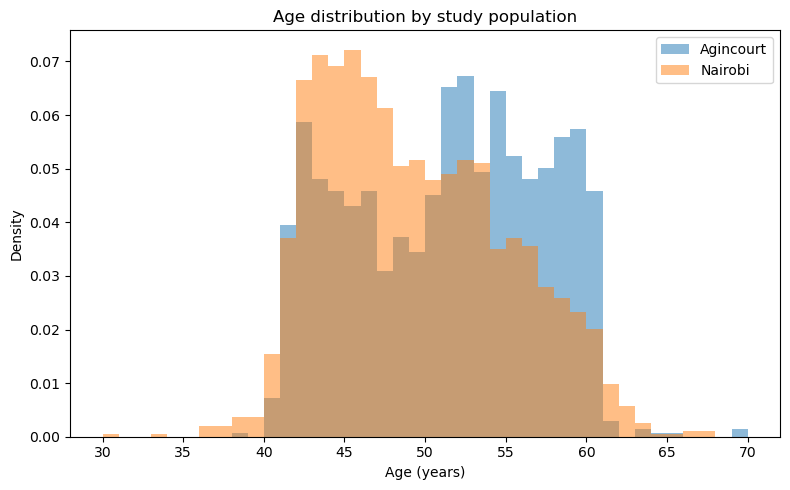

In [35]:
import matplotlib.pyplot as plt

# ============================================================
# PANEL A — AGE DISTRIBUTION
# ============================================================

all_age = pd.concat([age_ag, age_nai])

hist_bins = np.arange(
    np.floor(all_age.min()),
    np.ceil(all_age.max()) + 1,
    1
)

plt.figure(figsize=(8, 5))

plt.hist(
    age_ag,
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label='Agincourt'
)

plt.hist(
    age_nai,
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label='Nairobi'
)

plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Age distribution by study population')
plt.legend()
plt.tight_layout()
plt.show()

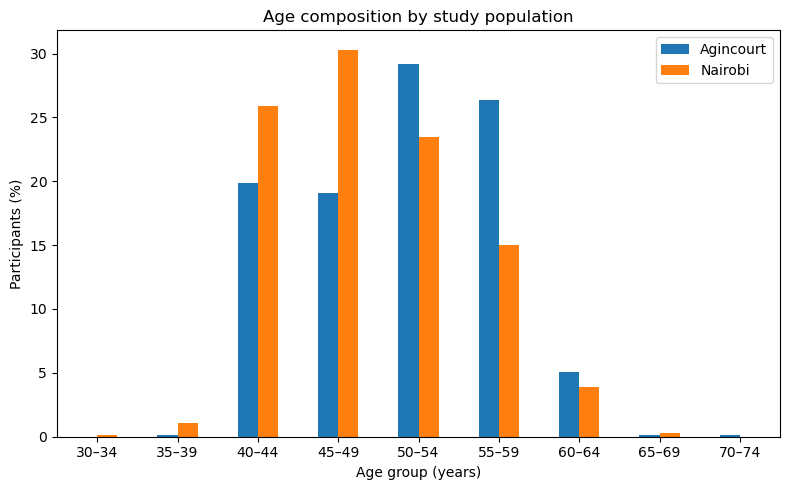

In [36]:
# ============================================================
# PANEL B — AGE-BAND DISTRIBUTION
# ============================================================

pivot_age = (
    age_band_counts
    .pivot(
        index='Age_band_label',
        columns='Site',
        values='Percent'
    )
)

pivot_age.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Age group (years)')
plt.ylabel('Participants (%)')
plt.title('Age composition by study population')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# AGE-SPECIFIC MULTIMORBIDITY BURDEN
# ============================================================

age_burden = (
    combined
    .dropna(subset=['Age_band_label', OUTCOME_COL])
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )[OUTCOME_COL]
    .agg(
        n='size',
        mean='mean',
        sd='std'
    )
    .reset_index()
)

age_burden['se'] = (
    age_burden['sd'] /
    np.sqrt(age_burden['n'])
)

age_burden['ci_low'] = (
    age_burden['mean'] -
    1.96 * age_burden['se']
)

age_burden['ci_high'] = (
    age_burden['mean'] +
    1.96 * age_burden['se']
)

display(age_burden)

,Site,Age_band_label,n,mean,sd,se,ci_low,ci_high
0,Agincourt,35–39,1,0.000000,NaN,NaN,NaN,NaN
1,Agincourt,40–44,278,0.521583,0.661937,0.039700,0.443770,0.599395
2,Agincourt,45–49,267,0.689139,0.712927,0.043630,0.603623,0.774654
3,Agincourt,50–54,407,0.798526,0.738590,0.036611,0.726769,0.870282
4,Agincourt,55–59,368,1.024457,0.826634,0.043091,0.939998,1.108915
5,Agincourt,60–64,71,0.929577,0.780548,0.092634,0.748015,1.111140
6,Agincourt,65–69,2,1.000000,0.000000,0.000000,1.000000,1.000000
7,Agincourt,70–74,1,2.000000,NaN,NaN,NaN,NaN
8,Nairobi,30–34,2,0.000000,0.000000,0.000000,0.000000,0.000000
9,Nairobi,35–39,22,0.272727,0.455842,0.097186,0.082243,0.463212


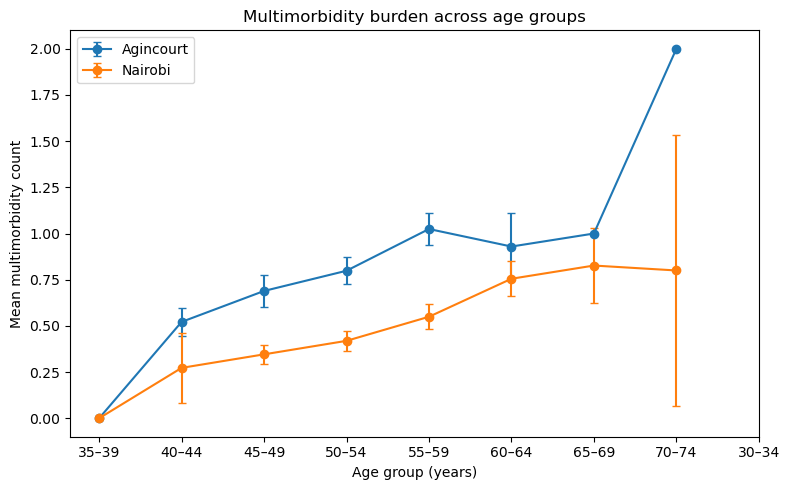

In [38]:
# ============================================================
# PANEL C — MEAN MULTIMORBIDITY COUNT BY AGE GROUP
# ============================================================

plt.figure(figsize=(8, 5))

for site in ['Agincourt', 'Nairobi']:

    temp = age_burden[
        age_burden['Site'] == site
    ].copy()

    x = np.arange(len(temp))

    plt.errorbar(
        x,
        temp['mean'],
        yerr=[
            temp['mean'] - temp['ci_low'],
            temp['ci_high'] - temp['mean']
        ],
        marker='o',
        capsize=3,
        label=site
    )

# use labels appearing in the data
age_labels = (
    age_burden['Age_band_label']
    .drop_duplicates()
    .tolist()
)

plt.xticks(
    np.arange(len(age_labels)),
    age_labels
)

plt.xlabel('Age group (years)')
plt.ylabel('Mean multimorbidity count')
plt.title('Multimorbidity burden across age groups')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

WHR_COL = 'waist_hip_r_c_phase1'   # change to your actual variable name

def continuous_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N_total': len(df),
        'N_available': len(x),
        'Missing_n': len(df) - len(x),
        'Missing_%': 100 * (len(df) - len(x)) / len(df),
        'Mean': x.mean(),
        'SD': x.std(),
        'Median': x.median(),
        'Q1': x.quantile(0.25),
        'Q3': x.quantile(0.75),
        'Min': x.min(),
        'Max': x.max()
    }

whr_summary = pd.DataFrame([
    continuous_summary(dff_ag, 'Agincourt', WHR_COL),
    continuous_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_summary.round(3))

,Site,N_total,N_available,Missing_n,Missing_%,Mean,SD,Median,Q1,Q3,Min,Max
0,Agincourt,1395,1395,0,0.0,0.901,0.076,0.90,0.85,0.95,0.59,1.16
1,Nairobi,1939,1939,0,0.0,0.894,0.256,0.88,0.84,0.93,0.65,9.02


In [40]:
whr_ag = pd.to_numeric(
    dff_ag[WHR_COL], errors='coerce'
).dropna()

whr_nai = pd.to_numeric(
    dff_nai[WHR_COL], errors='coerce'
).dropna()

# Standardized mean difference
pooled_sd = np.sqrt(
    (whr_ag.var(ddof=1) + whr_nai.var(ddof=1)) / 2
)

whr_smd = (
    whr_ag.mean() - whr_nai.mean()
) / pooled_sd

# KS test
ks_whr, p_whr = ks_2samp(whr_ag, whr_nai)

print(f'WHR SMD (Agincourt - Nairobi): {whr_smd:.3f}')
print(f'WHR KS statistic: {ks_whr:.3f}')
print(f'WHR KS p-value: {p_whr:.4g}')

WHR SMD (Agincourt - Nairobi): 0.035
WHR KS statistic: 0.082
WHR KS p-value: 3.009e-05


In [41]:
def whr_threshold_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N': len(x),
        'WHR >= 0.87 n': int((x >= 0.87).sum()),
        'WHR >= 0.87 %': 100 * (x >= 0.87).mean(),
        'WHR >= 0.90 n': int((x >= 0.90).sum()),
        'WHR >= 0.90 %': 100 * (x >= 0.90).mean()
    }

whr_thresholds = pd.DataFrame([
    whr_threshold_summary(dff_ag, 'Agincourt', WHR_COL),
    whr_threshold_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_thresholds.round(2))

,Site,N,WHR >= 0.87 n,WHR >= 0.87 %,WHR >= 0.90 n,WHR >= 0.90 %
0,Agincourt,1395,928,66.52,711,50.97
1,Nairobi,1939,1176,60.65,834,43.01


In [42]:
def whr_threshold_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N': len(x),
        'WHR >= 0.87 n': int((x >= 0.87).sum()),
        'WHR >= 0.87 %': 100 * (x >= 0.87).mean(),
        'WHR >= 0.90 n': int((x >= 0.90).sum()),
        'WHR >= 0.90 %': 100 * (x >= 0.90).mean()
    }

whr_thresholds = pd.DataFrame([
    whr_threshold_summary(dff_ag, 'Agincourt', WHR_COL),
    whr_threshold_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_thresholds.round(2))

,Site,N,WHR >= 0.87 n,WHR >= 0.87 %,WHR >= 0.90 n,WHR >= 0.90 %
0,Agincourt,1395,928,66.52,711,50.97
1,Nairobi,1939,1176,60.65,834,43.01


In [43]:
def prepare_age_whr(df, site):
    temp = df[[AGE_COL, WHR_COL, OUTCOME_COL]].copy()
    temp['Site'] = site

    temp['Age_band'] = pd.cut(
        temp[AGE_COL],
        bins=age_bins,
        right=False,
        include_lowest=True
    )

    temp['Age_band_label'] = temp['Age_band'].apply(
        lambda x: f"{int(x.left)}–{int(x.right - 1)}"
        if pd.notna(x) else np.nan
    )

    return temp

age_whr = pd.concat([
    prepare_age_whr(dff_ag, 'Agincourt'),
    prepare_age_whr(dff_nai, 'Nairobi')
], ignore_index=True)

whr_by_age = (
    age_whr[
        age_whr['Age_band_label'].isin(
            ['40–44', '45–49', '50–54', '55–59', '60–64']
        )
    ]
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )[WHR_COL]
    .agg(
        n='count',
        mean='mean',
        sd='std',
        median='median'
    )
    .reset_index()
)

whr_by_age['se'] = (
    whr_by_age['sd'] / np.sqrt(whr_by_age['n'])
)

whr_by_age['ci_low'] = (
    whr_by_age['mean'] - 1.96 * whr_by_age['se']
)

whr_by_age['ci_high'] = (
    whr_by_age['mean'] + 1.96 * whr_by_age['se']
)

display(whr_by_age.round(3))

,Site,Age_band_label,n,mean,sd,median,se,ci_low,ci_high
0,Agincourt,40–44,278,0.873,0.071,0.87,0.004,0.864,0.881
1,Agincourt,45–49,267,0.893,0.079,0.88,0.005,0.884,0.903
2,Agincourt,50–54,407,0.903,0.070,0.90,0.003,0.896,0.909
3,Agincourt,55–59,368,0.920,0.080,0.91,0.004,0.912,0.928
4,Agincourt,60–64,71,0.923,0.064,0.92,0.008,0.908,0.938
5,Nairobi,40–44,503,0.890,0.369,0.87,0.016,0.857,0.922
6,Nairobi,45–49,587,0.890,0.306,0.87,0.013,0.865,0.914
7,Nairobi,50–54,455,0.895,0.070,0.89,0.003,0.889,0.902
8,Nairobi,55–59,290,0.903,0.068,0.90,0.004,0.896,0.911
9,Nairobi,60–64,75,0.917,0.069,0.92,0.008,0.901,0.933


In [44]:
age_whr['WHR_ge_087'] = (
    age_whr[WHR_COL] >= 0.87
).astype(int)

age_whr['WHR_ge_090'] = (
    age_whr[WHR_COL] >= 0.90
).astype(int)

whr_threshold_by_age = (
    age_whr[
        age_whr['Age_band_label'].isin(
            ['40–44', '45–49', '50–54', '55–59', '60–64']
        )
    ]
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )
    .agg(
        n=(WHR_COL, 'count'),
        WHR_ge_087_pct=('WHR_ge_087', 'mean'),
        WHR_ge_090_pct=('WHR_ge_090', 'mean')
    )
    .reset_index()
)

whr_threshold_by_age['WHR_ge_087_pct'] *= 100
whr_threshold_by_age['WHR_ge_090_pct'] *= 100

display(whr_threshold_by_age.round(1))

,Site,Age_band_label,n,WHR_ge_087_pct,WHR_ge_090_pct
0,Agincourt,40–44,278,52.9,36.7
1,Agincourt,45–49,267,59.2,44.6
2,Agincourt,50–54,407,70.0,52.3
3,Agincourt,55–59,368,76.1,61.7
4,Agincourt,60–64,71,77.5,66.2
5,Nairobi,40–44,503,54.7,34.0
6,Nairobi,45–49,587,54.2,39.0
7,Nairobi,50–54,455,65.9,47.9
8,Nairobi,55–59,290,71.7,54.5
9,Nairobi,60–64,75,80.0,62.7


In [45]:
numeric_columns = [col for col in dff.columns \
                     if (is_numeric_dtype(dff[col])) \
                     & (col not in target_cols) \
                     & (dff[col].nunique() > 10)]

In [ ]:
# Defining the search space to be all the features except site, study_id, 
# and our created target_col and expectations columns

search_space1 = [col for col in dff.columns \
                if col not in \
                ['age_phase2','index','site',
       'diabetes_status_c_phase2', 'hypertension_status_phase2',
       'smoking_status_c_phase2', 'diabetes_history_phase2', 'mvpa_c_phase2',
       'weight_phase2', 'bmi_c_phase2', 'waist_circumference_phase2',
       'waist_hip_r_c_phase2', 'bp_sys_average_phase2','hypertension_status_c_phase1','diabetes_status_c_phase1','non_hdl_c_phase1',
       'bp_dia_average_phase2', 'fasting_confirmed_phase2','hip_circumference_phase1', 'hip_circumference_phase2',
       'glucose_result_phase2', 's_creatinine_phase2', 'insulin_result_phase2', 'cholesterol_1_phase2', 'friedewald_ldl_c_phase2',
       'triglycerides_phase2', 'non_hdl_c_phase2', 'egfr_c_phase2','acr_c_phase2', 'change_in_weight', 'change_in_bmi',
       'change_in_waist_hip_ratio', 'change_in_waist_circf','change_in_systolic_ave', 'change_in_diastolic_ave',
       'change_in_cholesterol', 'change_in_friedewald', 'change_in_hdl', 'bp_sys_average_phase1',
       'change_in_triglycerides', 'change_in_glucose','ckd_c_phase1', 'bp_dia_average_phase1', 'acr_c_phase1',
 'cvd_status_phase1','insulin_result_phase1','hdl_phase2','fasting_confirmation_phase1','weight_phase1','partnership_status_c_phase1',
       'change_in_s_creatinine', 'change_in_insulin', 'change_in_non_hdl','s_creatinine_phase1', 'glucose_result_phase1', 
       'change_in_egfr', 'change_in_acr', 'change_in_mvpa', 'MAP_phase1',#'diabetes_history_phase1', 'mvpa_c_phase1', 
       'MAP_phase2', 'MorbidityCount', 'expectationPoisson']]

In [ ]:
def get_str(x):
    # This function turns a pandas bin to a meaningful string
    s = str(round(x.left, 2)) + ' - ' + str(round(x.right,2))
    return s

def custom_qcut(ser, contiguous = True):
    # Get the rows that are actual numbers
    sub_ser = ser[(ser != -111) \
                     & (ser != -222) \
                     & (ser != -555) \
                     & (ser != -999)]
    
    if contiguous:
        # if contiguous, treat all the special numbers the same
        ser = ser.replace(-111 , -999)
        ser = ser.replace(-222 , -999)
        ser = ser.replace(-555 , -999)

    # Bin the actual numbers into 10 bins for scanning
    sub_ser = pd.qcut(sub_ser, 10, duplicates='drop')
    sub_ser = sub_ser.apply(get_str).astype(str)
    ser[list(sub_ser.index)] = sub_ser
    return ser
            

In [ ]:
def compress_contiguous(subset, contiguous):
    # Shorten a contiguous list e.g [0-9, 10-19] is converted to [0 - 19] 
    new = {}
    
    for col in subset:
        if col in contiguous:
            if isinstance(subset[col][0], (float,int)):
                new[col] = [str(c) for c in subset[col]]
                continue
            i = -1 if isinstance(subset[col][-1], str) else -2
            new[col] = [subset[col][0].split(' - ')[0] + ' - ' + subset[col][i].split(' - ')[-1]]
            new[col] = new[col] if i == -1 else new[col] + [str(subset[col][-1])]
        else:
            new[col] = [str(c) for c in subset[col]]
    return new

def translate_subset_to_rule(subset):
    # Print the subset as a rule for easier understanding
    desc = ''
    for key, value in subset.items():
        # desc += key + ' = {' + ' OR '.join(value) + '} AND' + '\n'
        desc += key + '{' + ' OR '.join(value) + '} AND' + ' '

    return desc[:-5].replace('_',' ').replace('{', '[').replace('}', ']')

def count_conditions(subset):
    # Split the string by 'AND' and 'OR'
    conditions = subset.replace("AND", "OR").split("OR")
    
    # Count the number of conditions
    condition_count = len(conditions)
    
    return condition_count

In [ ]:
dff = dff_ag.copy()

# This is now the expectation used by Autostrat
dff['expectationPoisson'] = dff['expectationPoisson_age']

contiguous = {}
dff_2 = dff.copy()

for col in numeric_columns:
    if col in search_space1:
        dff_2[col] = custom_qcut(dff_2[col].copy())

        bins = list(dff_2[col].unique())

        if -999 in bins:
            bins.remove(-999)

        bins = sorted(
            bins,
            key=lambda x: float(x.split(' - ')[0])
        )

        contiguous[col] = bins

In [ ]:
# %%time

import scipy.stats as stats

# Scan in the positive direction using defined penalties and num iters

scoring_function = Poisson(direction='positive')
scanner = MDSS(scoring_function)
penalty_values = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 6.5, 10]
# penalty_values = [0.3, 0.8, 1.0, 2.1, 3.5,4.5,5.5,6.5,7.5] # High risk Nairobi 
# penalty_values = [0.05, 0.1, 0.2, 0.5,0.8, 1.0,2.0,3.5, 4.5, 6.5, 9.5] # Low risk 
# penalty_values = [0.05, 0.4, 0.5, 0.8, 1.0,2.0,3.5, 4.0, 4.5] # High risk
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5,20.5] # Low risk
num_iters = 10
subset, score = scanner.scan(
    dff_2[search_space1],
    dff_2['MorbidityCount'],
    dff_2['expectationPoisson'],
    cpu=0.95,
    penalty=1.6,
    num_iters=num_iters,
    contiguous=contiguous.copy(),
    mode='ordinal'
)

In [ ]:
# %%time

import scipy.stats as stats

# Scan in the positive direction using defined penalties and num iters

scoring_function = Poisson(direction='positive')
scanner = MDSS(scoring_function)
penalty_values = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 6.5, 10]
# penalty_values = [0.3, 0.8, 1.0, 2.1, 3.5,4.5,5.5,6.5,7.5] # High risk Nairobi 
# penalty_values = [0.05, 0.1, 0.2, 0.5,0.8, 1.0,2.0,3.5, 4.5, 6.5, 9.5] # Low risk 
# penalty_values = [0.05, 0.4, 0.5, 0.8, 1.0,2.0,3.5, 4.0, 4.5] # High risk
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5,20.5] # Low risk
num_iters = 10
subset, score = scanner.scan(
    dff_2[search_space1],
    dff_2['MorbidityCount'],
    dff_2['expectationPoisson'],
    cpu=0.95,
    penalty=1.6,
    num_iters=num_iters,
    contiguous=contiguous.copy(),
    mode='ordinal'
)

